# Twitch Sponsorship Optimization Agent
## Component 1 - Data Collection and Preparation

**Course:** MGMT 590-037 - AI-Enhanced Optimization - Daniels School of Business
**Component owner:** Ethin DalPian
**Pipeline position:** Data -> Prediction -> Optimization -> Explanation (this notebook is the **Data** stage)

This notebook completes every item in **Component 1** of the project checklist. It ingests all three
provided datasets, validates them, engineers the pre-decision session feature set, segments creators with
k-means, builds a grouped train / test split, and prepares the player value dataset. Section numbers below
match the checklist exactly. The closing section maps each checklist line to where it is satisfied.

**Outputs written to disk** (for the Prediction layer, Component 2):
`sessions_prepared.csv`, `creator_segments.csv`, `creator_split.csv`, `players_prepared.csv`, plus a JSON
data-prep manifest.

---
## Setup - Cell 1 (all imports and configuration)

Per the team notebook rule, **every import lives in this single cell**. No later cell imports anything.

In [1]:
# ============================== CELL 1: ALL IMPORTS ==============================
# Standard library
import os
import json
import warnings
from pathlib import Path

# Scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import GroupShuffleSplit, GroupKFold

# --------------------------------------------------------------------------------
# Required packages (install if running from a clean environment):
#   pip install pandas numpy scikit-learn matplotlib
# Tested with: Python 3.11+, pandas 2.x, scikit-learn 1.3+, numpy 1.26+, matplotlib 3.8+
# --------------------------------------------------------------------------------

%matplotlib inline
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# ---- data location resolver (works regardless of the kernel working dir) -------
# VS Code does not always launch the kernel from the repo root, so a relative path
# like "data/raw/..." can miss. This probes the likely locations, uses the first
# that contains the data, and on failure prints exactly where it looked.
DATA_CANDIDATES = [
    Path("data/raw"),                 # standard project layout
    Path("../data/raw"),              # notebook sitting in a subfolder
    Path("data"),
    Path.cwd(),
    Path("/mnt/user-data/uploads"),   # course sandbox upload location
]

def resolve_data_dir(probe="twitch_df.csv"):
    for d in DATA_CANDIDATES:
        if (d / probe).exists():
            return d.resolve()
    searched = "\n".join(f"  - {d.resolve()}" for d in DATA_CANDIDATES)
    raise FileNotFoundError(
        f"Could not locate {probe}.\ncwd = {Path.cwd()}\nSearched:\n{searched}\n"
        "Add the correct folder to the top of DATA_CANDIDATES if your files live elsewhere."
    )

IN_DIR  = resolve_data_dir()                 # inputs are read-only
OUT_DIR = Path("outputs")                     # portable relative output folder
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Collected once and serialized at the end as the data-prep manifest.
manifest = {}

print("Imports loaded. Random state:", RANDOM_STATE)
print("Resolved data dir:", IN_DIR)
print("Output dir       :", OUT_DIR.resolve())

Imports loaded. Random state: 42
Resolved data dir: /mnt/user-data/uploads
Output dir       : /home/claude/outputs


---
## 1.1 Twitch session data (`twitch_df`)

Load the session table and run every validation the checklist lists. Each check prints a clear
PASS / FLAG line and is also recorded in the manifest so the report can cite it.

In [2]:
twitch = pd.read_csv(IN_DIR / "twitch_df.csv")

print("Loaded twitch_df")
print("  shape          :", twitch.shape)
print("  n creators     :", twitch["creator_id"].nunique())
print("  expected       : (39928, 16), 2000 creators")
twitch.head()

Loaded twitch_df
  shape          : (39928, 16)
  n creators     : 2000
  expected       : (39928, 16), 2000 creators


,creator_id,session,dow,start_hour,duration,unq_viewers,avg_viewers,5min_viewers,sponsored,sp_cost,active_users_1h,active_users_3h,purchases_1h,purchases_3h,creator_female,creator_followers
0,1,1,5,19,84,55594,39726,24843,0,NaN,41703,60275,14592,21765,0,1000552
1,1,2,7,20,108,39162,31691,16412,0,NaN,29382,42805,10282,11718,0,1000606
2,1,3,6,20,131,51135,45028,28788,0,NaN,38348,49699,13419,18857,0,1000669
3,1,4,2,17,125,48750,38544,25848,1,"15,394.0000",36563,45978,12785,15898,0,1000689
4,1,5,5,18,150,60877,46736,23886,1,"21,557.0000",45679,67621,15994,22238,0,1000750


In [3]:
# ---- 1.1 validation suite ---------------------------------------------------
checks_11 = {}

# Expected dimensions
checks_11["rows_eq_39928"]     = (twitch.shape[0] == 39928)
checks_11["cols_eq_16"]        = (twitch.shape[1] == 16)
checks_11["creators_eq_2000"]  = (twitch["creator_id"].nunique() == 2000)

# No duplicate session rows per creator_id + session
n_dup = int(twitch.duplicated(subset=["creator_id", "session"]).sum())
checks_11["no_duplicate_sessions"] = (n_dup == 0)

# Missingness: sp_cost is null for unsponsored by design; nothing else should be null
na_counts = twitch.isna().sum()
unexpected_na = na_counts.drop(labels=["sp_cost"]).sum()
checks_11["no_unexpected_nulls"] = (unexpected_na == 0)

# sponsored strictly binary
checks_11["sponsored_binary"] = set(twitch["sponsored"].unique()) <= {0, 1}

# purchases_1h / purchases_3h non-negative integers
def _nonneg_int(col):
    return pd.api.types.is_integer_dtype(twitch[col]) and (twitch[col].min() >= 0)
checks_11["purchases_1h_nonneg_int"] = _nonneg_int("purchases_1h")
checks_11["purchases_3h_nonneg_int"] = _nonneg_int("purchases_3h")

# Consistency: sp_cost present iff sponsored == 1
sp_present = twitch["sp_cost"].notna()
flag_cost_no_spon = int(((sp_present) & (twitch["sponsored"] == 0)).sum())   # cost present, sponsored 0
flag_spon_no_cost = int(((~sp_present) & (twitch["sponsored"] == 1)).sum())  # sponsored 1, cost missing
checks_11["sp_cost_consistent_with_sponsored"] = (flag_cost_no_spon == 0 and flag_spon_no_cost == 0)

print("Missingness (non-zero only):")
print(na_counts[na_counts > 0].to_string(), "\n")

print("sp_cost present vs sponsored cross-tab:")
print(pd.crosstab(twitch["sponsored"], sp_present.rename("sp_cost_present")), "\n")

print(f"{'CHECK':40s} RESULT")
print("-" * 52)
for name, ok in checks_11.items():
    print(f"{name:40s} {'PASS' if ok else 'FLAG'}")

print(f"\nDuplicate sessions                 : {n_dup}")
print(f"sp_cost present but sponsored == 0 : {flag_cost_no_spon}")
print(f"sponsored == 1 but sp_cost missing : {flag_spon_no_cost}")

manifest["section_1_1"] = {
    "checks": {k: bool(v) for k, v in checks_11.items()},
    "duplicate_sessions": n_dup,
    "flag_cost_present_unsponsored": flag_cost_no_spon,
    "flag_sponsored_no_cost": flag_spon_no_cost,
    "sp_cost_null_count": int(na_counts["sp_cost"]),
    "n_sessions": int(twitch.shape[0]),
    "n_creators": int(twitch["creator_id"].nunique()),
}

Missingness (non-zero only):
sp_cost    19900 

sp_cost present vs sponsored cross-tab:
sp_cost_present  False  True 
sponsored                    
0                19900      0
1                    0  20028 

CHECK                                    RESULT
----------------------------------------------------
rows_eq_39928                            PASS
cols_eq_16                               PASS
creators_eq_2000                         PASS
no_duplicate_sessions                    PASS
no_unexpected_nulls                      PASS
sponsored_binary                         PASS
purchases_1h_nonneg_int                  PASS
purchases_3h_nonneg_int                  PASS
sp_cost_consistent_with_sponsored        PASS

Duplicate sessions                 : 0
sp_cost present but sponsored == 0 : 0
sponsored == 1 but sp_cost missing : 0


**Reading the 1.1 result.** `sp_cost` is null on exactly the unsponsored rows and on no others, so the
field behaves exactly as documented and there are zero consistency flags. `sponsored` is strictly `{0, 1}`,
the purchase counts are non-negative integers, and there are no duplicate sessions. The observed `sp_cost`
minimum is **$500**, which confirms the spend floor referenced in the optimization formulation. The session
table passes 1.1 with no remediation required.

---
## 1.2 Feature engineering (session level)

Goal: a **pre-decision** feature set that excludes every post-session outcome. The four post-session
columns (`active_users_1h`, `active_users_3h`, `purchases_1h`, `purchases_3h`) are quarantined from model
inputs and carried only as labels.

**Documented encoding choices**

* **`dow` -> cyclical sin / cos.** Day of week is periodic (the codebook maps 1 = Sunday ... 7 = Saturday),
  so a cyclical encoding places Saturday and Sunday adjacent in feature space rather than at opposite ends
  of an ordinal scale. We keep the original `dow` as well for interpretability.
* **`start_hour`** is left as a raw numeric pre-decision feature (observed range 10 to 23). Whether to give
  it a cyclical encoding is left to the modeler in Component 2; it is not required for clustering.
* **`sp_cost` model fill.** For use as a model feature we create `sp_cost_model` = `sp_cost` with unsponsored
  sessions filled to 0. The original `sp_cost` column is preserved untouched so the null-by-design semantics
  remain available downstream.
* **Standardized continuous features** (`creator_followers`, `unq_viewers`, `avg_viewers`, `5min_viewers`,
  `duration`) are produced at session level with a saved scaler. Note that the operative standardization for
  segmentation happens on the creator-level aggregates in Section 1.3; these session-level standardized
  columns are provided for any session-level model that wants them.

In [4]:
POST_SESSION_OUTCOMES = ["active_users_1h", "active_users_3h", "purchases_1h", "purchases_3h"]
CONT_FEATURES = ["creator_followers", "unq_viewers", "avg_viewers", "5min_viewers", "duration"]

sessions = twitch.copy()

# --- cyclical day-of-week (period 7, dow in 1..7) ---
theta = 2.0 * np.pi * (sessions["dow"] - 1) / 7.0
sessions["dow_sin"] = np.sin(theta)
sessions["dow_cos"] = np.cos(theta)

# --- sp_cost model feature: 0 for unsponsored, preserve original null column ---
sessions["sp_cost_model"] = sessions["sp_cost"].fillna(0.0)
assert sessions["sp_cost"].isna().sum() == twitch["sp_cost"].isna().sum(), "original sp_cost must be preserved"

# --- session-level standardized continuous features (saved scaler) ---
session_scaler = StandardScaler()
std_cols = [f"{c}__z" for c in CONT_FEATURES]
sessions[std_cols] = session_scaler.fit_transform(sessions[CONT_FEATURES])

# --- explicit pre-decision feature list (no post-session outcomes) ---
pre_decision_features = [
    "creator_followers", "unq_viewers", "avg_viewers", "5min_viewers", "duration",
    "dow", "dow_sin", "dow_cos", "start_hour", "creator_female",
    "sponsored", "sp_cost_model",
]
leakage = [c for c in pre_decision_features if c in POST_SESSION_OUTCOMES]
assert not leakage, f"post-session outcome leaked into features: {leakage}"

print("Engineered columns added:", ["dow_sin", "dow_cos", "sp_cost_model"] + std_cols)
print("\nPre-decision feature set (model inputs):")
for f in pre_decision_features:
    print("  ", f)
print("\nQuarantined post-session outcomes (labels only):", POST_SESSION_OUTCOMES)
print("\nLeakage check: PASS (no outcome columns in feature set)")

sessions[["creator_id", "session", "dow", "dow_sin", "dow_cos",
          "sponsored", "sp_cost", "sp_cost_model"]].head()

Engineered columns added: ['dow_sin', 'dow_cos', 'sp_cost_model', 'creator_followers__z', 'unq_viewers__z', 'avg_viewers__z', '5min_viewers__z', 'duration__z']

Pre-decision feature set (model inputs):
   creator_followers
   unq_viewers
   avg_viewers
   5min_viewers
   duration
   dow
   dow_sin
   dow_cos
   start_hour
   creator_female
   sponsored
   sp_cost_model

Quarantined post-session outcomes (labels only): ['active_users_1h', 'active_users_3h', 'purchases_1h', 'purchases_3h']

Leakage check: PASS (no outcome columns in feature set)


,creator_id,session,dow,dow_sin,dow_cos,sponsored,sp_cost,sp_cost_model
0,1,1,5,-0.4339,-0.9010,0,NaN,0.0000
1,1,2,7,-0.7818,0.6235,0,NaN,0.0000
2,1,3,6,-0.9749,-0.2225,0,NaN,0.0000
3,1,4,2,0.7818,0.6235,1,"15,394.0000","15,394.0000"
4,1,5,5,-0.4339,-0.9010,1,"21,557.0000","21,557.0000"


---
## 1.3 Creator-level aggregation and k-means segmentation

Aggregate to one row per `creator_id` using the four checklist features: median followers, median unique
viewers, median duration, and the sponsored session rate. We then segment creators with k-means.

**Why a log transform before standardizing (documented decision).** Median followers and median unique
viewers are extremely right-skewed (skew near 13), driven by a handful of mega-creators with roughly one
million followers. If we standardize the raw values, those few outliers dominate the distance metric: k-means
then "discovers" a split that simply isolates the outliers, producing a misleadingly high silhouette at
k = 2 and starving every real segment of structure. Applying `log1p` to the two skewed count features before
standardizing (duration and sponsored rate are already well behaved) brings skew near 0.4 and yields stable,
well populated segments. Duration and sponsored rate are standardized without a log step.

In [5]:
CREATOR_AGG_FEATURES = ["med_followers", "med_unq_viewers", "med_duration", "spon_rate"]

creators = (
    sessions.groupby("creator_id")
    .agg(
        med_followers=("creator_followers", "median"),
        med_unq_viewers=("unq_viewers", "median"),
        med_duration=("duration", "median"),
        spon_rate=("sponsored", "mean"),
        n_sessions=("session", "size"),
    )
    .reset_index()
)

print("Creator table shape:", creators.shape)
print("\nSkew of aggregated features (raw):")
for c in CREATOR_AGG_FEATURES:
    print(f"  {c:16s} skew = {creators[c].skew():6.2f}")

# log-transform the two heavily skewed count features
creators["log_med_followers"]   = np.log1p(creators["med_followers"])
creators["log_med_unq_viewers"] = np.log1p(creators["med_unq_viewers"])
print("\nSkew after log1p:")
for c in ["log_med_followers", "log_med_unq_viewers"]:
    print(f"  {c:20s} skew = {creators[c].skew():6.2f}")

cluster_input_cols = ["log_med_followers", "log_med_unq_viewers", "med_duration", "spon_rate"]
cluster_scaler = StandardScaler()
X_cluster = cluster_scaler.fit_transform(creators[cluster_input_cols])
print("\nClustering feature matrix:", X_cluster.shape, "(log-transformed + standardized)")
creators.head()

Creator table shape: (2000, 6)

Skew of aggregated features (raw):
  med_followers    skew =  13.38
  med_unq_viewers  skew =  13.19
  med_duration     skew =   0.18
  spon_rate        skew =  -0.03

Skew after log1p:
  log_med_followers    skew =   0.40
  log_med_unq_viewers  skew =   0.37

Clustering feature matrix: (2000, 4) (log-transformed + standardized)


,creator_id,med_followers,med_unq_viewers,med_duration,spon_rate,n_sessions,log_med_followers,log_med_unq_viewers
0,1,"1,000,986.0000","48,750.0000",119.0000,0.4667,15,13.8165,10.7945
1,2,"1,015,824.5000","50,583.0000",124.0000,0.5385,26,13.8312,10.8314
2,3,"983,888.5000","46,402.5000",131.0000,0.5000,24,13.7993,10.7451
3,4,"977,156.5000","44,808.0000",146.5000,0.4375,16,13.7924,10.7102
4,5,"1,050,563.0000","56,349.0000",120.0000,0.5517,29,13.8648,10.9393


In [6]:
# ---- k-means sweep over k = 2..8: inertia (elbow) and silhouette --------------
ks = list(range(2, 9))
sweep = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_cluster)
    sweep.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X_cluster, km.labels_),
    })
sweep_df = pd.DataFrame(sweep)
print(sweep_df.to_string(index=False))
manifest["section_1_3_kmeans_sweep"] = sweep_df.to_dict(orient="records")

 k    inertia  silhouette
 2 5,899.4524      0.2654
 3 4,605.7814      0.2539
 4 4,023.8900      0.2290
 5 3,544.9854      0.2289
 6 3,152.5187      0.2216
 7 2,829.1994      0.2253
 8 2,580.4463      0.2230


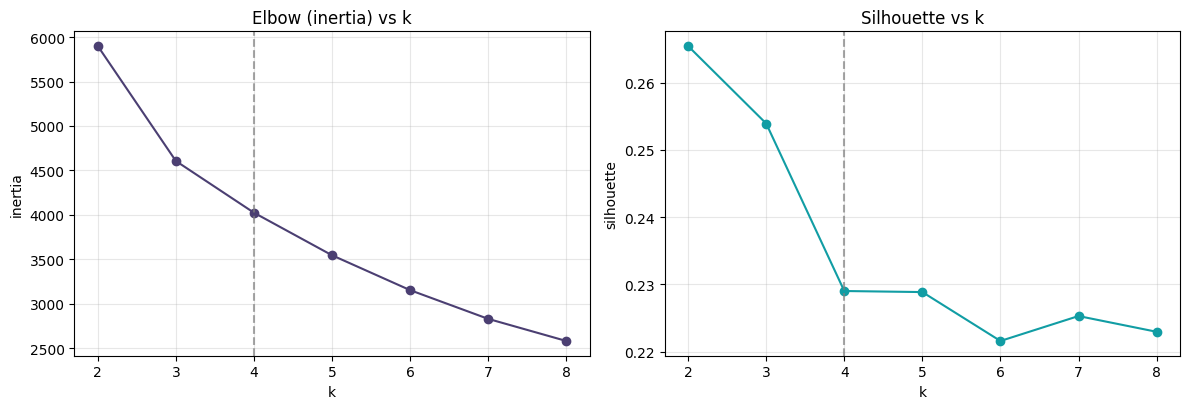

In [7]:
# ---- elbow + silhouette plots -------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].plot(sweep_df["k"], sweep_df["inertia"], "o-", color="#4B3F72")
ax[0].set_title("Elbow (inertia) vs k"); ax[0].set_xlabel("k"); ax[0].set_ylabel("inertia")
ax[0].axvline(4, ls="--", color="gray", alpha=.7)
ax[1].plot(sweep_df["k"], sweep_df["silhouette"], "o-", color="#119DA4")
ax[1].set_title("Silhouette vs k"); ax[1].set_xlabel("k"); ax[1].set_ylabel("silhouette")
ax[1].axvline(4, ls="--", color="gray", alpha=.7)
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

**Choosing k (documented rationale).** On the log-standardized features the silhouette is essentially flat
across k from 3 to 8 (roughly 0.22 to 0.27) and the inertia curve declines smoothly with no sharp elbow.
This is expected: creator behavior here is a continuum rather than a set of cleanly separated clusters, so no
internal metric singles out a winner. The choice is therefore driven by the operational constraints the
checklist names:

* **k = 5 isolates a degenerate 5-creator segment** (the mega-creators). That cluster is far too small and
  too narrow in spend to fit an identifiable Hill curve, and it trips the checklist's own "merge or redefine"
  rule for data-sparse segments.
* **k = 4 keeps every segment well populated** (roughly 300 to 600 creators each) with a wide `sp_cost`
  spread and no near-degenerate sponsored rate, so each segment can support a stable response-curve fit.
* The checklist sets k = 4 or 5 as the practical ceiling before curves go data-sparse.

We therefore select **k = 4**, which absorbs the mega-creators into the high-reach segment instead of
stranding them alone.

In [8]:
K_FINAL = 4
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10).fit(X_cluster)
creators["segment"] = kmeans_final.labels_

# merge segment label back to session data
sessions = sessions.merge(creators[["creator_id", "segment"]], on="creator_id", how="left")
assert sessions["segment"].isna().sum() == 0, "every session must receive a segment label"
print(f"k = {K_FINAL} segments assigned to {creators.shape[0]} creators and "
      f"merged back to {sessions.shape[0]} sessions.\n")

# ---- per-segment profile + sponsored-rate and sp_cost-spread flags ------------
rows = []
for s in sorted(creators["segment"].unique()):
    cre = creators[creators["segment"] == s]
    sess_s = sessions[sessions["segment"] == s]
    spon_sess = sess_s[sess_s["sponsored"] == 1]["sp_cost"]
    seg_spon_rate = sess_s["sponsored"].mean()
    # flags from the checklist
    flag_spon = (seg_spon_rate < 0.05) or (seg_spon_rate > 0.95)         # near-entirely (un)sponsored
    iqr_ratio = (spon_sess.quantile(.75) - spon_sess.quantile(.25)) / spon_sess.median()
    flag_spend = iqr_ratio < 0.25                                        # spend variation too narrow
    rows.append({
        "segment": s,
        "n_creators": len(cre),
        "n_sessions": len(sess_s),
        "spon_rate": round(seg_spon_rate, 3),
        "med_followers": round(cre["med_followers"].median()),
        "med_unq_viewers": round(cre["med_unq_viewers"].median()),
        "spcost_p25": round(spon_sess.quantile(.25)),
        "spcost_med": round(spon_sess.median()),
        "spcost_p75": round(spon_sess.quantile(.75)),
        "spend_iqr_ratio": round(iqr_ratio, 2),
        "FLAG_spon_rate": flag_spon,
        "FLAG_narrow_spend": flag_spend,
    })
seg_profile = pd.DataFrame(rows)
print(seg_profile.to_string(index=False))

any_flag = bool(seg_profile[["FLAG_spon_rate", "FLAG_narrow_spend"]].any().any())
print("\nAny segment flagged for sponsored-rate imbalance or narrow spend:", any_flag)
manifest["section_1_3_segment_profile"] = seg_profile.to_dict(orient="records")
manifest["section_1_3_k_final"] = K_FINAL

k = 4 segments assigned to 2000 creators and merged back to 39928 sessions.

 segment  n_creators  n_sessions  spon_rate  med_followers  med_unq_viewers  spcost_p25  spcost_med  spcost_p75  spend_iqr_ratio  FLAG_spon_rate  FLAG_narrow_spend
       0         604       12039     0.6050          99336             4999        1468        2275        3226           0.7700           False              False
       1         574       11249     0.4150          96419             4753        1462        2280        3182           0.7500           False              False
       2         512       10444     0.4720         125980             6324        1897        2938        4089           0.7500           False              False
       3         310        6196     0.5080          66074             3277         895        1433        2051           0.8100           False              False

Any segment flagged for sponsored-rate imbalance or narrow spend: False


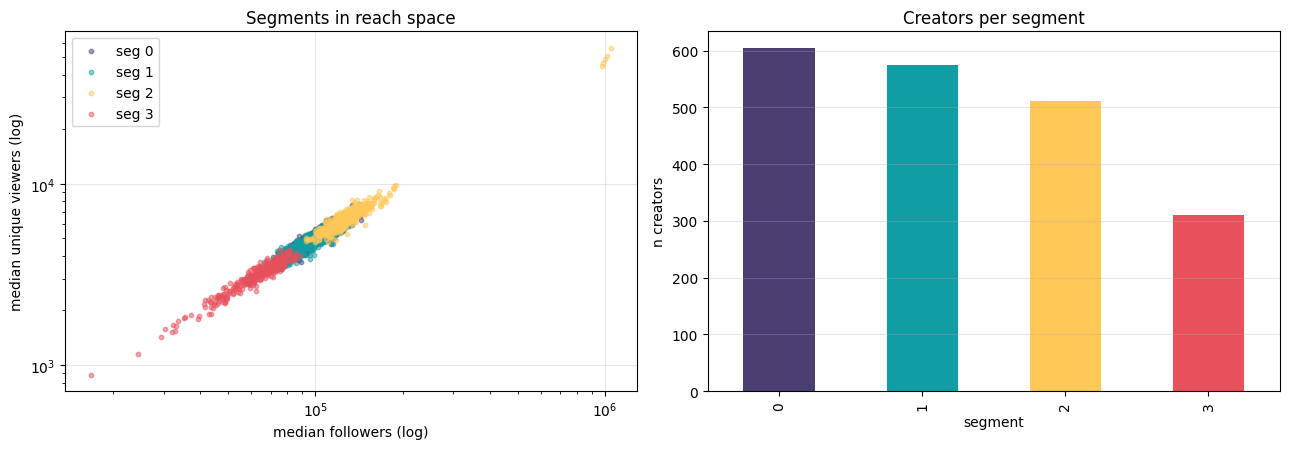

In [9]:
# ---- visualize segments in the two reach dimensions ---------------------------
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
palette = ["#4B3F72", "#119DA4", "#FFC857", "#E8505B", "#5C946E"]
for s in sorted(creators["segment"].unique()):
    cre = creators[creators["segment"] == s]
    ax[0].scatter(cre["med_followers"], cre["med_unq_viewers"], s=10, alpha=.5,
                  color=palette[s], label=f"seg {s}")
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("median followers (log)"); ax[0].set_ylabel("median unique viewers (log)")
ax[0].set_title("Segments in reach space"); ax[0].legend(); ax[0].grid(alpha=.3)

seg_profile.set_index("segment")["n_creators"].plot.bar(
    ax=ax[1], color=[palette[s] for s in seg_profile["segment"]])
ax[1].set_title("Creators per segment"); ax[1].set_ylabel("n creators"); ax[1].grid(alpha=.3, axis="y")
plt.tight_layout(); plt.show()

---
## 1.4 Train / test split (grouped on `creator_id`)

The split is **grouped on `creator_id`** so that no creator appears in both train and test. We hold out
roughly 15% of creators as the final test set and set up grouped k-fold cross validation on the remaining
creators for model selection. We then confirm the segment distribution is roughly balanced across the split.

In [10]:
TEST_FRACTION = 0.15
N_FOLDS = 5

creator_ids = creators["creator_id"].values
segments    = creators["segment"].values

# grouped holdout: split creators (groups) so none crosses the boundary
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_FRACTION, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(creator_ids, groups=creator_ids))

creators["split"] = "train"
creators.loc[creators.index[test_idx], "split"] = "test"

train_creators = set(creators.loc[creators["split"] == "train", "creator_id"])
test_creators  = set(creators.loc[creators["split"] == "test",  "creator_id"])

# hard guarantee: no creator overlap
overlap = train_creators & test_creators
assert len(overlap) == 0, "creator leakage between train and test"

print(f"Creators -> train: {len(train_creators)}  test: {len(test_creators)}  "
      f"(test fraction = {len(test_creators)/len(creators):.1%})")
print("Creator overlap between splits:", len(overlap), "(must be 0)")

# segment balance across splits (column-normalized so each split sums to 1)
bal = pd.crosstab(creators["segment"], creators["split"], normalize="columns")
print("\nSegment share within each split:")
print(bal.to_string())
max_gap = float((bal["train"] - bal["test"]).abs().max())
print(f"\nLargest train vs test segment-share gap: {max_gap:.3f} (roughly balanced if small)")

# propagate split flag to session level
sessions = sessions.merge(creators[["creator_id", "split"]], on="creator_id", how="left")
print("\nSessions per split:")
print(sessions["split"].value_counts().to_string())

Creators -> train: 1700  test: 300  (test fraction = 15.0%)
Creator overlap between splits: 0 (must be 0)

Segment share within each split:
split     test  train
segment              
0       0.3100 0.3006
1       0.2900 0.2865
2       0.2433 0.2582
3       0.1567 0.1547

Largest train vs test segment-share gap: 0.015 (roughly balanced if small)

Sessions per split:
split
train    33926
test      6002


In [11]:
# ---- grouped k-fold CV on the TRAIN creators (for Component 2 model selection) ----
train_only = creators[creators["split"] == "train"].reset_index(drop=True)
gkf = GroupKFold(n_splits=N_FOLDS)
fold_summary = []
for fold, (tr, va) in enumerate(gkf.split(train_only, groups=train_only["creator_id"])):
    tr_c = set(train_only.loc[tr, "creator_id"])
    va_c = set(train_only.loc[va, "creator_id"])
    assert not (tr_c & va_c), "fold leakage"
    fold_summary.append({"fold": fold, "train_creators": len(tr_c), "val_creators": len(va_c)})
fold_df = pd.DataFrame(fold_summary)
print(f"GroupKFold ({N_FOLDS} folds) on {len(train_only)} train creators - no creator crosses a fold:")
print(fold_df.to_string(index=False))

manifest["section_1_4"] = {
    "test_fraction_target": TEST_FRACTION,
    "n_train_creators": len(train_creators),
    "n_test_creators": len(test_creators),
    "creator_overlap": len(overlap),
    "max_segment_share_gap": round(max_gap, 4),
    "n_cv_folds": N_FOLDS,
    "segment_balance": bal.round(4).reset_index().to_dict(orient="records"),
}

GroupKFold (5 folds) on 1700 train creators - no creator crosses a fold:
 fold  train_creators  val_creators
    0            1360           340
    1            1360           340
    2            1360           340
    3            1360           340
    4            1360           340


---
## 1.5 Player dataset (`train_df`, `test_df`)

Load the player tables for the value model. Confirm the two dependent variables are present in `train_df`,
quantify the spend sparsity, list the calibration-period features, and lock the two outcome columns out of
the feature set so they can never be used as predictors.

In [12]:
players_train = pd.read_csv(IN_DIR / "train_df.csv")
players_test  = pd.read_csv(IN_DIR / "test_df.csv")

print("train_df shape:", players_train.shape, "(expected 12000 players)")
print("test_df  shape:", players_test.shape)

OUTCOME_COLS = ["dv_purchase_amt", "dv_churn"]
ID_COL = "account_id"

# confirm dependent variables present in train
have_dv = [c for c in OUTCOME_COLS if c in players_train.columns]
print("\nDependent variables present in train_df:", have_dv)
assert set(OUTCOME_COLS) <= set(players_train.columns), "train_df missing a dependent variable"

# test_df is the held-out scoring set and is not expected to carry the dv columns
print("Dependent variables present in test_df :",
      [c for c in OUTCOME_COLS if c in players_test.columns],
      "(held-out scoring set - dv columns withheld by design)")

# sparsity of purchase amount
zero_rate = (players_train["dv_purchase_amt"] == 0).mean()
n_spenders = int((players_train["dv_purchase_amt"] > 0).sum())
print(f"\ndv_purchase_amt == 0 share : {zero_rate:.3%}  (checklist notes ~92%)")
print(f"spenders (dv_purchase_amt > 0): {n_spenders}  (checklist notes ~947)")
print("dv_churn values:", sorted(players_train["dv_churn"].unique()))

train_df shape: (12000, 29) (expected 12000 players)
test_df  shape: (3000, 27)

Dependent variables present in train_df: ['dv_purchase_amt', 'dv_churn']
Dependent variables present in test_df : [] (held-out scoring set - dv columns withheld by design)

dv_purchase_amt == 0 share : 92.108%  (checklist notes ~92%)
spenders (dv_purchase_amt > 0): 947  (checklist notes ~947)
dv_churn values: [np.int64(0), np.int64(1)]


In [13]:
# ---- calibration-period features for the value model --------------------------
# Outcomes are prediction-period and must never be used as predictors.
calibration_features = [c for c in players_train.columns
                        if c not in OUTCOME_COLS + [ID_COL]]

print(f"{len(calibration_features)} calibration-period features identified:")
print("  " + ", ".join(calibration_features))

# guarantee no outcome leaks into the feature set
leak = [c for c in calibration_features if c in OUTCOME_COLS]
assert not leak, f"outcome column leaked into features: {leak}"
print("\nOutcome-leakage check: PASS - dv_purchase_amt and dv_churn excluded from features")

# the test set should expose exactly the same calibration features
missing_in_test = [c for c in calibration_features if c not in players_test.columns]
print("Calibration features missing from test_df:", missing_in_test, "(should be empty)")

manifest["section_1_5"] = {
    "n_train_players": int(players_train.shape[0]),
    "n_test_players": int(players_test.shape[0]),
    "dv_present_in_train": have_dv,
    "dv_zero_share": round(float(zero_rate), 5),
    "n_spenders": n_spenders,
    "n_calibration_features": len(calibration_features),
    "calibration_features": calibration_features,
    "outcome_cols": OUTCOME_COLS,
}
players_train[calibration_features].describe().T.head(12)

26 calibration-period features identified:
  matches, active_days, wins, kills, kills_bots, assists, deaths, pmins, golds, unq_maps, unq_chrs, avg_matches_pd, max_matches_pd, avg_wins_pd, max_wins_pd, lw_match_rate, days_since_last_sign_in, days_since_sign_up, purchase_amt, purchase_freq, has_premium, chat_rate_pm, time_to_first_play, high_spd_internet, resolution, tutorial_progress

Outcome-leakage check: PASS - dv_purchase_amt and dv_churn excluded from features
Calibration features missing from test_df: [] (should be empty)


,count,mean,std,min,25%,50%,75%,max
matches,"12,000.0000",42.8423,75.9572,1.0000,4.0000,11.0000,45.0000,895.0000
active_days,"12,000.0000",6.2396,7.0043,1.0000,1.0000,3.0000,9.0000,28.0000
wins,"12,000.0000",18.4729,31.2961,0.0000,2.0000,6.0000,20.0000,398.0000
kills,"12,000.0000",188.5364,342.2068,0.0000,12.0000,49.0000,198.0000,"4,965.0000"
kills_bots,"12,000.0000","2,035.5729","4,085.3627",0.0000,115.0000,417.0000,"1,920.0000","49,895.0000"
assists,"12,000.0000",318.2568,588.6415,0.0000,22.7500,83.0000,329.0000,"7,013.0000"
deaths,"12,000.0000",176.2159,313.7257,0.0000,13.0000,47.0000,187.0000,"4,193.0000"
pmins,"12,000.0000",583.9075,"1,059.7189",0.0000,44.1100,147.3600,607.3700,"14,331.5200"
golds,"12,000.0000","661,746.3587","2,196,895.4247",0.0000,"33,441.0000","113,116.0000","518,966.0000","61,481,860.0000"
unq_maps,"12,000.0000",4.3967,3.1110,1.0000,2.0000,4.0000,6.0000,18.0000


---
## Save prepared artifacts

Write the prepared tables and a JSON manifest to `/mnt/user-data/outputs` for the Prediction layer.

In [14]:
sessions_out_cols = (
    ["creator_id", "session", "segment", "split", "dow", "dow_sin", "dow_cos",
     "start_hour", "duration", "creator_followers", "unq_viewers", "avg_viewers",
     "5min_viewers", "creator_female", "sponsored", "sp_cost", "sp_cost_model"]
    + [f"{c}__z" for c in CONT_FEATURES]
    + POST_SESSION_OUTCOMES        # outcomes carried as labels, clearly separated
)

sessions[sessions_out_cols].to_csv(OUT_DIR / "sessions_prepared.csv", index=False)
creators.to_csv(OUT_DIR / "creator_segments.csv", index=False)
creators[["creator_id", "segment", "split"]].to_csv(OUT_DIR / "creator_split.csv", index=False)
players_train.to_csv(OUT_DIR / "players_prepared.csv", index=False)

manifest["pre_decision_features"] = pre_decision_features
manifest["post_session_outcomes"] = POST_SESSION_OUTCOMES
manifest["random_state"] = RANDOM_STATE
with open(OUT_DIR / "data_prep_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2, default=str)

print("Written to", OUT_DIR, ":")
for p in ["sessions_prepared.csv", "creator_segments.csv", "creator_split.csv",
          "players_prepared.csv", "data_prep_manifest.json"]:
    print("  ", p)

Written to outputs :
   sessions_prepared.csv
   creator_segments.csv
   creator_split.csv
   players_prepared.csv
   data_prep_manifest.json


---
## Component 1 completion summary

| Checklist item | Where satisfied | Result |
|---|---|---|
| **1.1** Load `twitch_df` (39,928 x 16, 2,000 creators) | 1.1 | PASS, dimensions confirmed |
| 1.1 No duplicate `creator_id`+`session` | 1.1 | 0 duplicates |
| 1.1 Missingness (`sp_cost` null only for unsponsored) | 1.1 | confirmed, no unexpected nulls |
| 1.1 `sponsored` strictly binary | 1.1 | `{0,1}` |
| 1.1 `purchases_1h/3h` non-negative integers | 1.1 | PASS |
| 1.1 Flag `sp_cost` vs `sponsored` inconsistency | 1.1 | 0 flags |
| **1.2** Pre-decision feature set, outcomes excluded | 1.2 | leakage check PASS |
| 1.2 Encode `dow` (choice documented) | 1.2 | cyclical sin / cos |
| 1.2 Standardize continuous features for clustering | 1.2 / 1.3 | session scaler + creator scaler saved |
| 1.2 Fill `sp_cost` to 0 as model feature, preserve null | 1.2 | `sp_cost_model` added, original kept |
| **1.3** Aggregate to creator level (4 features) | 1.3 | one row per creator |
| 1.3 Standardize before clustering | 1.3 | log1p + StandardScaler |
| 1.3 k-means sweep k=2..8, elbow + silhouette | 1.3 | swept and plotted |
| 1.3 Select k and document rationale | 1.3 | k = 4, rationale documented |
| 1.3 Assign segment, merge back to sessions | 1.3 | every session labeled |
| 1.3 Flag near-degenerate sponsored rate | 1.3 | none flagged |
| 1.3 Flag narrow `sp_cost` spread per cluster | 1.3 | none flagged |
| **1.4** Grouped split on `creator_id` | 1.4 | 0 creator overlap |
| 1.4 ~15% holdout + grouped k-fold CV | 1.4 | 15% test, 5 fold GroupKFold |
| 1.4 Segment distribution balanced across splits | 1.4 | small share gap |
| **1.5** Load `train_df`, confirm dv columns | 1.5 | both present |
| 1.5 Note ~92% zero `dv_purchase_amt` | 1.5 | confirmed |
| 1.5 Identify calibration-period features | 1.5 | listed |
| 1.5 Treat dv columns as outcomes only | 1.5 | leakage check PASS |

**Handoff to Component 2 (Prediction layer).** The four CSVs above plus the manifest give the modeler a
labeled, leakage-checked session table with segment and split flags, the creator segment definitions, the
grouped split assignment, and the prepared player value table. No post-session outcome and no player
dependent variable sits in any feature list.